Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.
%%SLOAN: major dataset in astronomy

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)

Download the SDSS quasara data

In [2]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
# data = data[:100000] #%%useful trick: trial and error with few data!

z = data['redshift']


- Upsample this distribution in two ways, using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)

(Hint: `scipy.stats` is your best friend)

- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

(Hint: `astropy.cosmology` is another close friend). The best-fit cosmological model from the Plack data is:

In [3]:
import astropy
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

(array([8.93425258e-03, 3.88902706e-02, 1.01780393e-01, 1.63269109e-01,
        2.22130014e-01, 3.02888639e-01, 3.21633049e-01, 3.06567448e-01,
        3.32319114e-01, 3.47910258e-01, 3.60523319e-01, 3.35472379e-01,
        3.57019691e-01, 3.70158705e-01, 3.75238557e-01, 3.69807933e-01,
        4.05019394e-01, 4.17982356e-01, 4.67034126e-01, 4.55120772e-01,
        4.72990300e-01, 5.30800225e-01, 4.92609550e-01, 4.90333277e-01,
        4.81047590e-01, 4.82625287e-01, 5.52521522e-01, 5.92989691e-01,
        5.45689455e-01, 5.59354825e-01, 5.16959737e-01, 6.06829036e-01,
        5.25368435e-01, 5.07150710e-01, 4.72463711e-01, 3.90129406e-01,
        3.49662459e-01, 3.61049262e-01, 2.99208838e-01, 2.63648297e-01,
        2.20378443e-01, 1.84115854e-01, 1.45575260e-01, 1.48553990e-01,
        1.25430020e-01, 1.09313314e-01, 8.88166750e-02, 7.56784480e-02,
        7.05981818e-02, 6.74449131e-02, 5.83352126e-02, 6.60434604e-02,
        7.98828062e-02, 1.05459319e-01, 9.72257838e-02, 1.112398

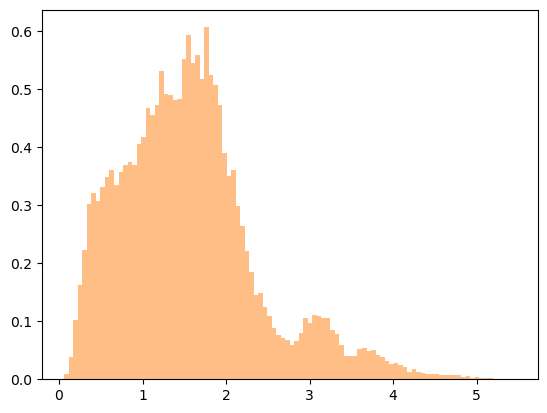

In [10]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

bins = 100

plt.hist(z, density=True,bins=bins, color="C1", histtype='stepfilled', alpha=0.5)

### REJECTION SAMPLING

100


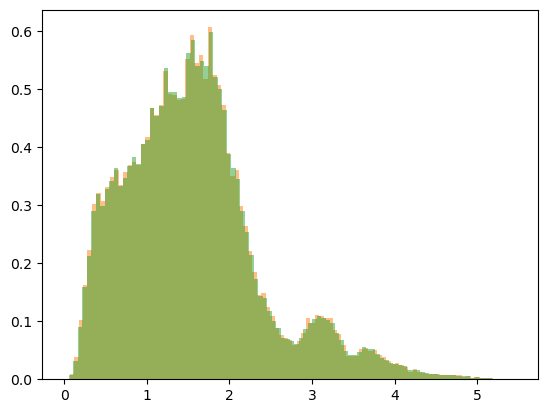

In [12]:
plt.hist(z, density=True,bins=bins, color="C1", histtype='stepfilled', alpha=0.5)
hist, bin_edges = np.histogram(z, bins=bins)


if True:
    N=1000000
    x_unif = np.random.uniform(0, bin_edges[-1], N) #selects the last value of bin_edges
    y_unif = np.random.uniform(0, hist.max(), N)

    x_up = []

    print(len(hist))
    for i in range(N):

        if (y_unif[i] < hist[np.digitize(x_unif[i], bin_edges)-1]): #digitize returns the bin position; -1 for indexing
            x_up.append(x_unif[i])



    plt.hist(x_up, density=True,bins=bins, color="C2", histtype='stepfilled', alpha=0.5)
    plt.show()


### INVERSE TRANSFORM

In [15]:
# "inverting" the histogram
def ecdf(x):

    sorted_data = np.sort(z)  # Sort the predefined data
    # Count how many values are less than or equal to `x`
    count = np.sum(sorted_data <= x)
    # ECDF value is the ratio of count to total number of data points
    return count / len(z)

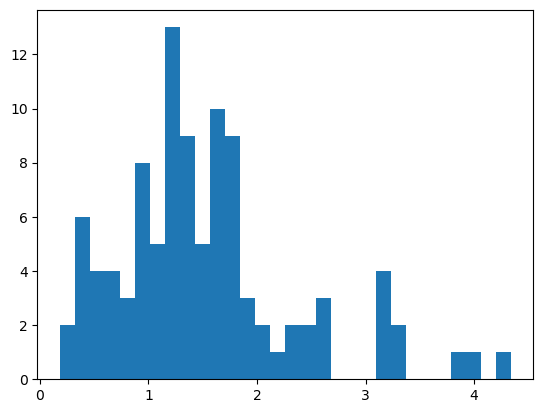

In [20]:
import scipy.optimize

eps = np.random.uniform(0,1,100)

# Example: Narrow the range of the search
# min_bound = np.percentile(z, 1)  # 5th percentile
# max_bound = np.percentile(z, 99) # 95th percentile

# samples = [scipy.optimize.brentq(lambda x: ecdf(x) - e, min_bound, max_bound) for e in eps]


# Using a vanilla root finder, which solves for cdf(h)=eps i.e. finds the zero of the function cdf(x)-eps
#%% solving inverse cdf numerically using a root finder
samples = [ scipy.optimize.brentq(lambda h: ecdf(h)-e, np.min(z), np.max(z)) for e in eps]

plt.hist(samples, bins=30)  # Plot histogram of samples
plt.show()

#tempi di esecuzione lunghissimi (quasi 5 min per 1000 punti)